# Long-Only Equity Momentum — by rebalance frequency

Two long-only S&P 500 momentum strategies (cross-sectional & time-series) on
iShares IVV holdings (survivorship-bias-free, point-in-time). This notebook is
organised **by rebalance frequency** — the shared signal/cost setup first, then a
parallel **Monthly / Weekly / Daily** treatment, then a cross-frequency comparison.

**Code layout** (split from the old monolith; `import momentum_strategies as ms`
still re-exports everything):
`data.py` (DataLoader, MarketData) · `signals.py` (momentum + IC) · `costs.py`
(cost models) · `backtester.py` (Backtester, metrics, walk-forward, presets) ·
`analytics.py` (sweeps, dashboards, I/O).

**Results layout:** `results/shared/` (signal, costs, data) · `results/monthly|weekly|daily/`
(each with `figures/ figure_data/ metrics/ weights/`) · `results/comparison/`.

**Contents.** §1 data · §2 signal & IC · §3 cost model · **§4 monthly** ·
**§5 weekly** · **§6 daily** · §7 cross-frequency comparison · §8 conclusions.

> Data: monthly snapshots 2006→; the scraper went **daily in late-2022**, so the
> weekly/daily studies cover ~2022-11→2026-06 only (short, recent, momentum-friendly
> — indicative, not comparable to the 20-year monthly base case).

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms          # aggregator: data/signals/costs/backtester/analytics
pd.set_option("display.float_format", lambda x: f"{x:,.4f}"); pd.set_option("display.max_columns", 40)

RES = "results"
for sub in ["shared", "monthly", "weekly", "daily", "comparison"]:
    for kind in ["figures", "figure_data", "metrics", "weights"]:
        os.makedirs(f"{RES}/{sub}/{kind}", exist_ok=True)
print("loaded ms with", len([x for x in dir(ms) if not x.startswith('_')]), "public symbols")

loaded ms with 54 public symbols


## 1. Data — point-in-time panels at three frequencies

`DataLoader(freq=...)` builds month-end / weekly (W-FRI) / trading-day panels,
filtering to equities and de-splitting returns via the `shares` column. Weekly and
daily auto-restrict to the dense sub-monthly era (~2022-11→).

,monthly,weekly,daily
start,2006-10-31,2022-11-11,2022-11-08
end,2026-06-30,2026-06-19,2026-06-17
n_periods,231,189,936
n_unique_names,1046,585,585
avg_names_per_month,502.4675,503.3598,503.1261
min_names_per_month,499,503,501
max_names_per_month,507,506,505


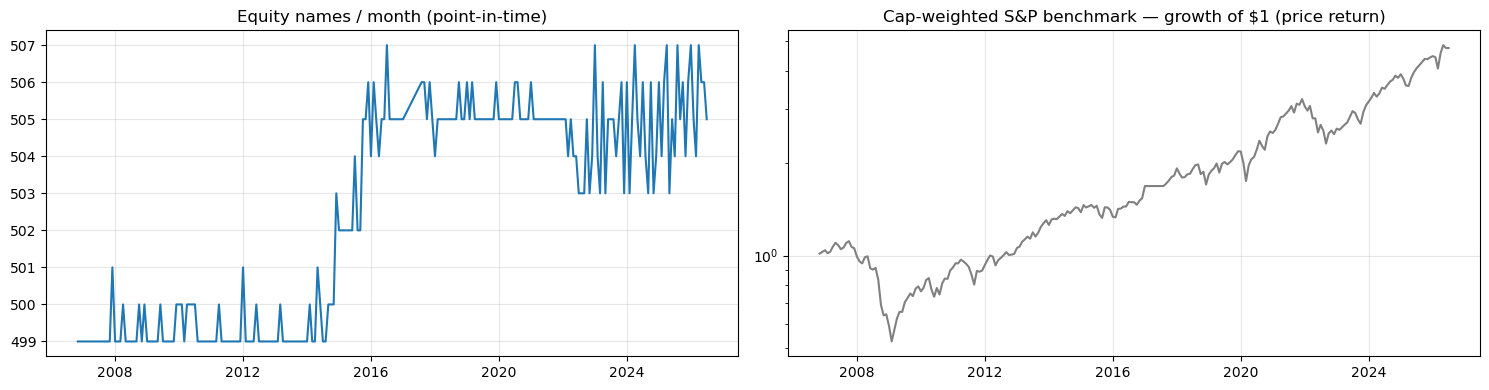

In [2]:
md_m  = ms.DataLoader("data").load()                 # monthly  (ppy=12)
md_w  = ms.DataLoader("data", freq="W").load()        # weekly   (ppy=52)
md_d  = ms.DataLoader("data", freq="D").load()        # daily    (ppy=252)
summ = pd.DataFrame({"monthly": md_m.summary(), "weekly": md_w.summary(), "daily": md_d.summary()})
summ = summ.rename(index={"n_months": "n_periods"})
display(summ)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
n = md_m.prices.notna().sum(axis=1); ax[0].plot(n.index, n.values); ax[0].set_title("Equity names / month (point-in-time)"); ax[0].grid(alpha=.3)
beq = (1 + md_m.benchmark.fillna(0)).cumprod(); ax[1].plot(beq.index, beq.values, color="grey"); ax[1].set_yscale("log")
ax[1].set_title("Cap-weighted S&P benchmark — growth of $1 (price return)"); ax[1].grid(alpha=.3)
pd.DataFrame({"n_names": n, "benchmark_ret": md_m.benchmark, "benchmark_equity": beq}).to_csv(f"{RES}/shared/figure_data/data_overview.csv")
plt.tight_layout(); plt.show()

## 2. Signal & Information Coefficient (shared)

The signal is **risk-adjusted momentum** (trailing return ÷ trailing vol). IC =
cross-sectional rank correlation of the signal with the forward return. Computed on
the monthly panel (the canonical horizon); raw vs risk-adjusted vs blended.

Mean monthly rank-IC vs 1-month forward return:


,mean_ic,ic_ir,t_stat,p_value,hit_rate,n_months
raw 12-1,0.0102,0.0514,0.7587,0.4488,0.5321,218.0000
risk-adj 12-1,0.0152,0.0805,1.1888,0.2358,0.5459,218.0000
blended 3/6/12,0.0048,0.0259,0.3821,0.7027,0.5183,218.0000


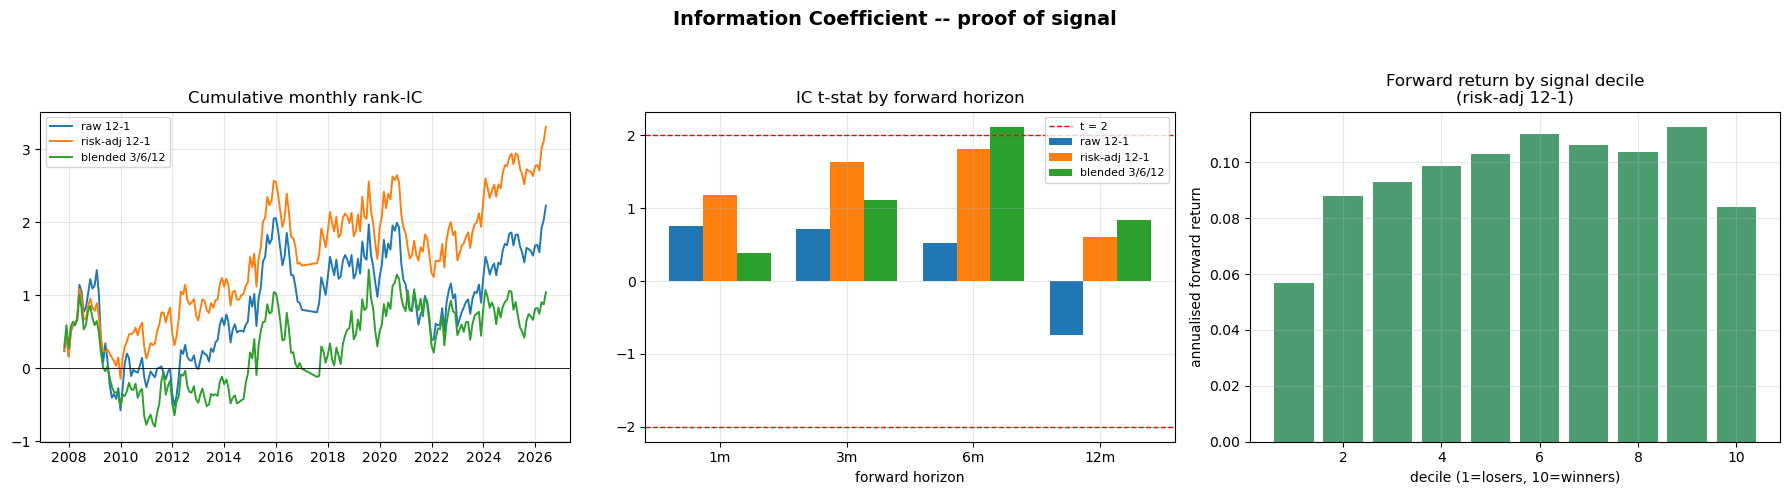

In [3]:
xs_cfg, ts_cfg = ms.DEFAULT_XS, ms.DEFAULT_TS
sig_raw   = ms.momentum_signal(md_m.prices, 12, 1, risk_adjusted=False)
sig_ra    = ms.build_signal(md_m, xs_cfg)
sig_blend = ms.blended_momentum_signal(md_m.prices, md_m.returns, (3, 6, 12))
signals = {"raw 12-1": sig_raw, "risk-adj 12-1": sig_ra, "blended 3/6/12": sig_blend}
ic_summary = pd.DataFrame({k: {kk: ms.information_coefficient(s, md_m.returns)[kk]
                               for kk in ("mean_ic","ic_ir","t_stat","p_value","hit_rate","n_months")}
                           for k, s in signals.items()}).T
print("Mean monthly rank-IC vs 1-month forward return:"); display(ic_summary)
fig, _ = ms.plot_ic_analysis(md_m, signals, primary="risk-adj 12-1",
                             fig_path=f"{RES}/shared/figures/ic_analysis.png",
                             data_dir=f"{RES}/shared/figure_data", slug="ic_analysis")
plt.show()

Risk-adjusting roughly doubles the IC; it peaks at 3–6m (t≈1.8) and the
blended signal clears t≈2.1 at 6m. The decile sort rises from losers to winners
(extreme-winner reversal) — the edge is mostly *avoiding losers*.

## 3. Transaction-cost model (shared, realistic, data-driven)

`RealisticCostModel` = **FX 15 bps** + **commission 0** + **half-spread**
(= 0.01 × daily vol, data-supported shape, ~1–3 bps) + **square-root impact**
(ADV from `market_value`, AUM-scaled). Used at **$100M** for all headline results.
FX dominates (~80%+); the biggest lever is gross vs **net** FX (held USD balance).

XS monthly — net Sharpe / annual cost drag:
  flat 5.0bps                  0.489 / 0.27%
  realistic gross-FX           0.435 / 0.99%
  realistic net-FX (USD bal)   0.488 / 0.29%

Cost breakdown ($100M, gross-FX):


fx           0.0082
commission   0.0000
spread       0.0009
impact       0.0008
total        0.0099
Name: ann_cost_drag, dtype: float64

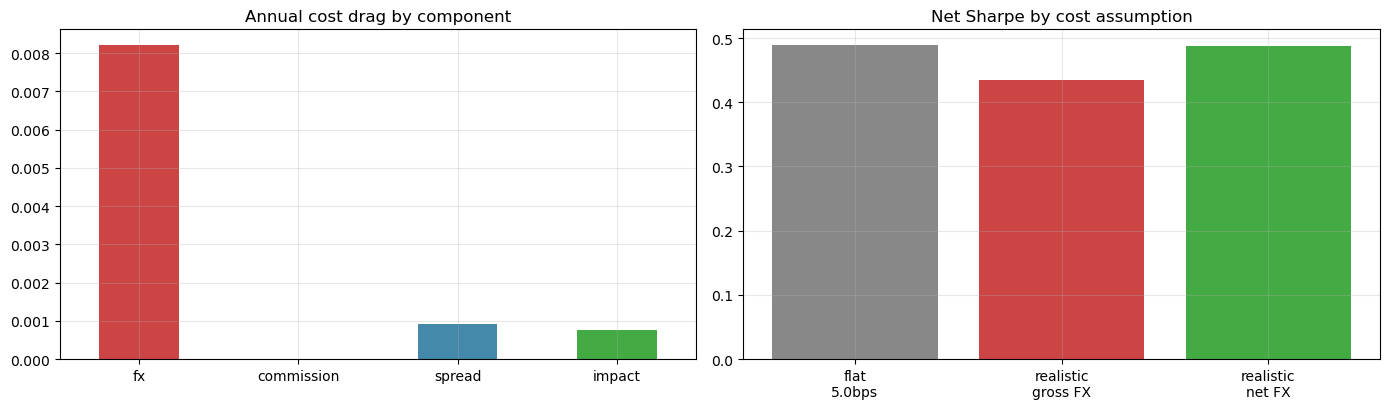

In [4]:
AUM = 1e8
cost_model = ms.RealisticCostModel(fx_bps=15.0, commission_bps=0.0, aum=AUM)
flat_tcost_bps = 5.0
bd = ms.cost_breakdown(md_m, sig_ra, xs_cfg, fx_bps=15.0, aum=AUM); bd.to_csv(f"{RES}/shared/figure_data/cost_breakdown.csv")
g = ms.metrics_from_result(ms.Backtester(md_m, ms.RealisticCostModel(fx_bps=15, fx_on="gross", aum=AUM)).run(sig_ra, xs_cfg))
n = ms.metrics_from_result(ms.Backtester(md_m, ms.RealisticCostModel(fx_bps=15, fx_on="net",   aum=AUM)).run(sig_ra, xs_cfg))
f = ms.metrics_from_result(ms.Backtester(md_m, ms.LinearCostModel(flat_tcost_bps)).run(sig_ra, xs_cfg))
print("XS monthly — net Sharpe / annual cost drag:")
for lab, mm in [(f"flat {flat_tcost_bps}bps", f), ("realistic gross-FX", g), ("realistic net-FX (USD bal)", n)]:
    print(f"  {lab:28s} {mm['Sharpe']:.3f} / {mm['AnnTCost']:.2%}")
print("\nCost breakdown ($100M, gross-FX):"); display(bd.round(4))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
bd.drop("total").plot.bar(ax=ax[0], color=["#c44","#888","#48a","#4a4"]); ax[0].set_title("Annual cost drag by component"); ax[0].tick_params(axis="x", rotation=0); ax[0].grid(alpha=.3)
ax[1].bar([f"flat\n{flat_tcost_bps}bps","realistic\ngross FX","realistic\nnet FX"], [f["Sharpe"],g["Sharpe"],n["Sharpe"]], color=["#888","#c44","#4a4"]); ax[1].set_title("Net Sharpe by cost assumption"); ax[1].grid(alpha=.3)
fig.savefig(f"{RES}/shared/figures/cost_model.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

### Per-frequency runner

`run_frequency` runs both strategies at one frequency: 2×3 dashboard, current
weights, and the metric set — all saved under `results/<freq>/`. The Monthly /
Weekly / Daily sections below each call it, then add frequency-specific analyses.

In [5]:
def run_frequency(market, ppy, configs, cost_model, outdir, label, dashboards=True):
    bt = ms.Backtester(market, cost_model, periods_per_year=ppy)
    figs, fdata, wts, mets = (f"{outdir}/figures", f"{outdir}/figure_data",
                              f"{outdir}/weights", f"{outdir}/metrics")
    results, metrics = {}, {}
    for name, cfg in configs.items():
        sig = ms.build_signal(market, cfg)
        res = bt.run(sig, cfg)
        slug = f"{name.lower()}_momentum"
        results[name] = (res, sig, cfg)
        metrics[f"{name} ({label})"] = ms.metrics_from_result(res)
        ms.save_weights(res, f"{wts}/{slug}", sectors=market.sectors)
        if dashboards:
            ms.plot_strategy_dashboard(res, market, sig, f"{label} — {name} momentum",
                                       fig_path=f"{figs}/{slug}_dashboard.png", data_dir=fdata, slug=slug)
            plt.show()
    tbl = ms.save_metrics_table(metrics, f"{mets}/metrics.csv")
    return results, tbl

## 4. Monthly rebalance (20-year base case)

The full 2006→2026 history. Both strategies are **long-only with no leverage** (`max_leverage=1`): vol-targeting only ever scales *down* toward cash when forecast vol exceeds 15%, so realised vol sits **at or below ~15%**. XS is **signal-weighted** (position size ∝ cross-sectional momentum rank). Followed by **walk-forward** out-of-sample validation and the **turnover penalty**.

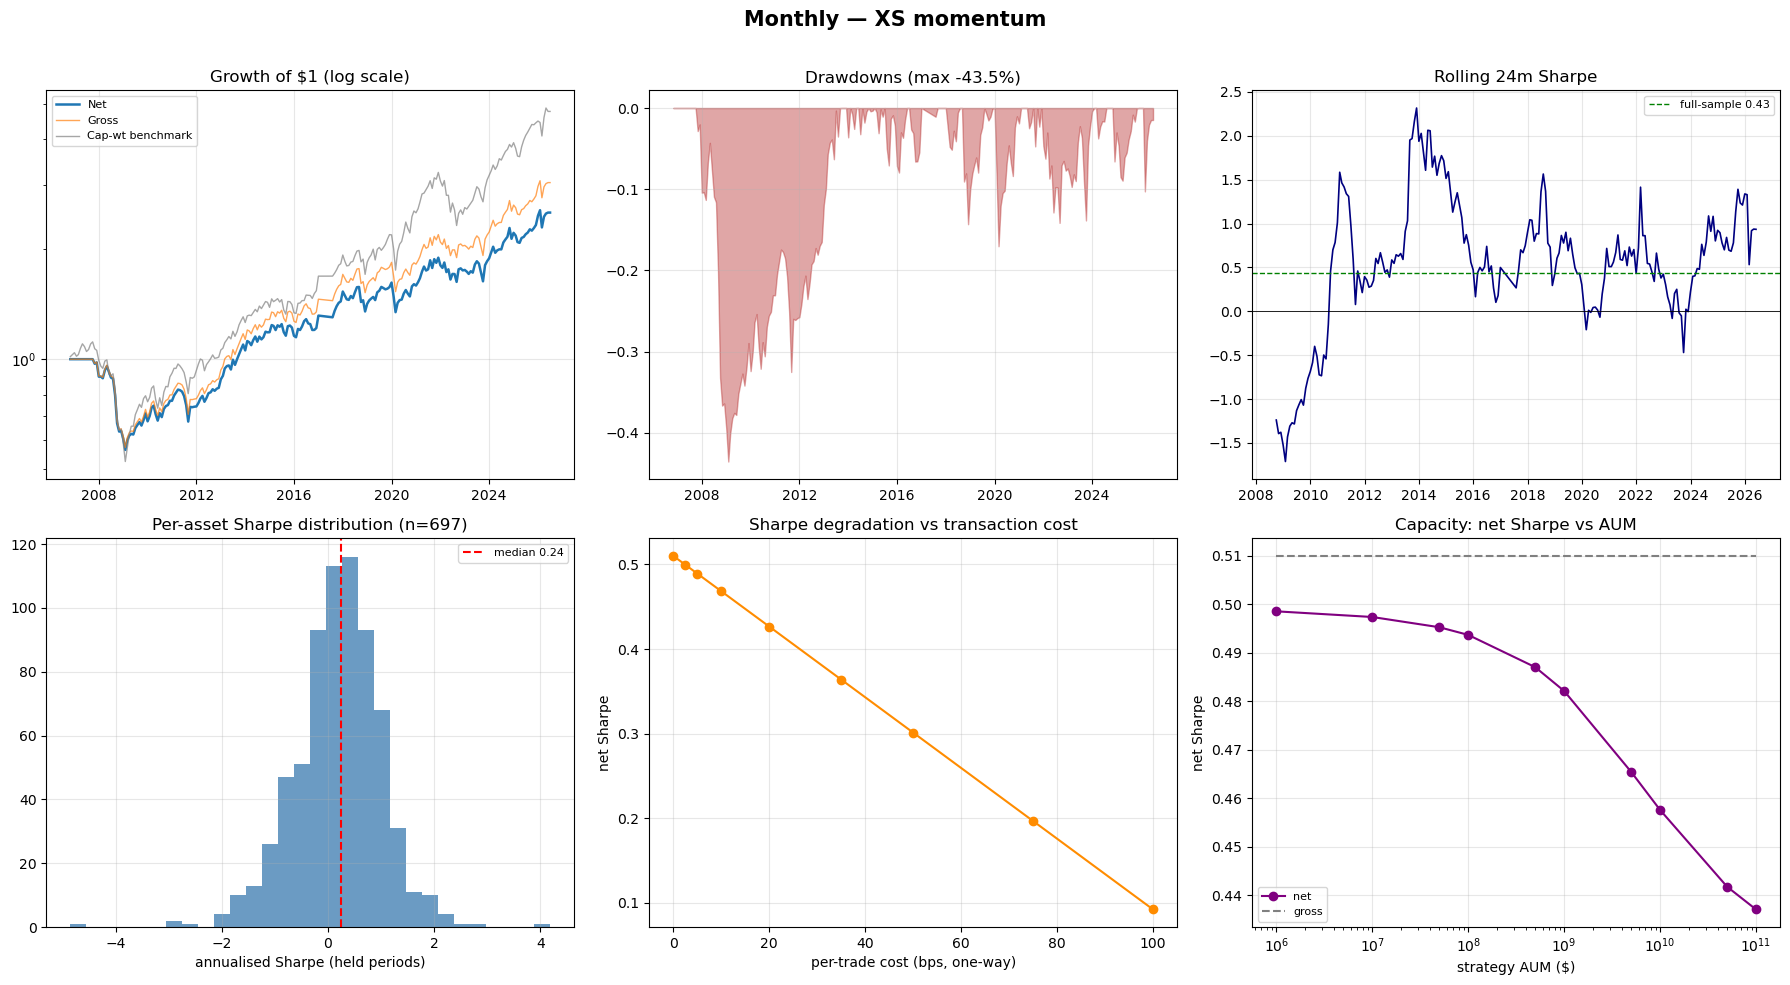

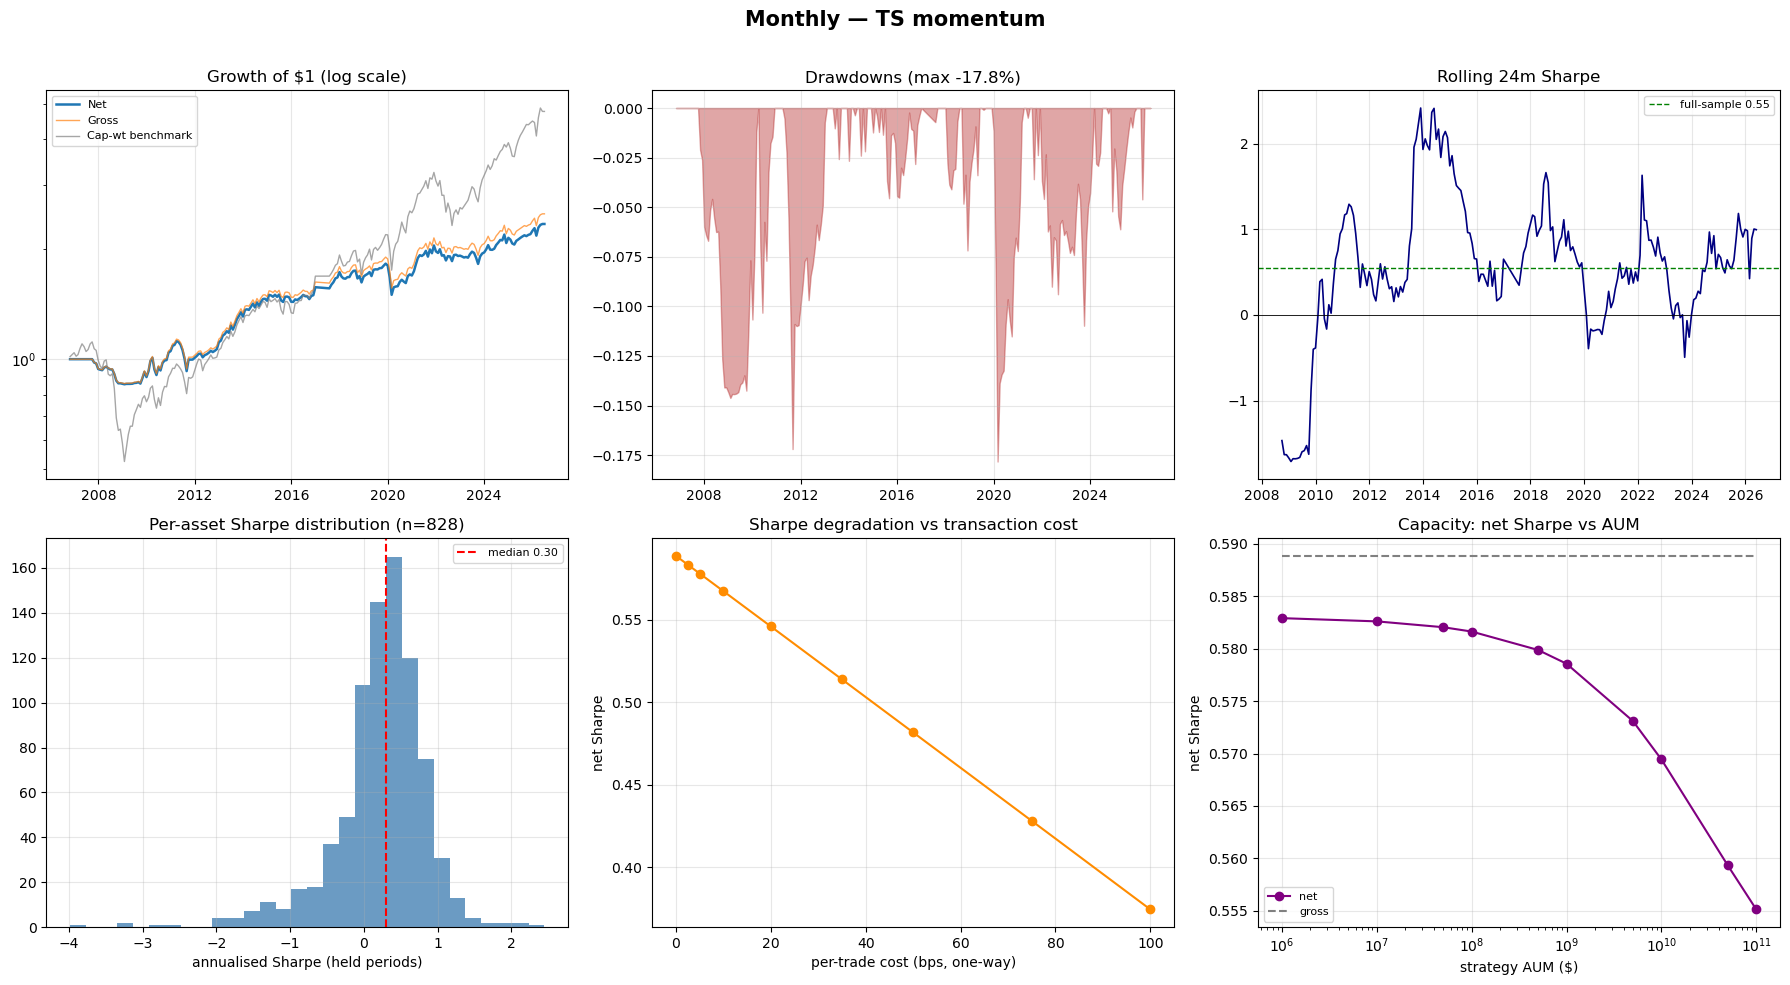

,XS (Monthly),TS (Monthly)
CAGR,0.0493,0.0454
Ann.Return,0.0569,0.0484
Ann.Vol,0.1310,0.0878
Sharpe,0.4346,0.5510
Sortino,0.5521,0.7110
Calmar,0.1134,0.2549
MaxDrawdown,-0.4351,-0.1782
WinRate,0.5783,0.5783
ProfitFactor,1.3946,1.5482
AvgWin,0.0290,0.0197


Current XS book: 96 names, gross 68%; TS: 282 names.


In [6]:
res_m, tbl_m = run_frequency(md_m, 12, {"XS": ms.DEFAULT_XS, "TS": ms.DEFAULT_TS},
                             cost_model, f"{RES}/monthly", "Monthly")
display(tbl_m)
xs_m, sig_m, _ = res_m["XS"]; ts_m, tsig_m, _ = res_m["TS"]
print("Current XS book: %d names, gross %.0f%%; TS: %d names." %
      (len(xs_m.current_weights()), 100*xs_m.current_weights().sum(), len(ts_m.current_weights())))

### Cross-sectional weighting — equal vs signal vs sweet-spot

Is the book "all equal, no cross-sectional bet"? Three within-book schemes are
available (`weighting=`), shown below — the plot overlays their weight profiles:
* **equal** — flat across the top quantile (the bet is purely the *selection*).
* **signal** — weight ∝ momentum rank (overweights the strongest).
* **sweet_spot** — equal across the bulk, **tapering the extreme winners** (the
  decile-10 group that mean-reverts, per §2).

Honest finding (tested at all three frequencies): **equal is the robust best** — `signal` drags monthly (the D10 reversal), and `sweet_spot` matches equal monthly but is *worse* weekly/daily and churns more. So within-book reweighting doesn't add value here: **the cross-sectional edge is the selection**, not the sizing. Equal is the default; the tilts are one flag away.

net Sharpe by within-book weighting (monthly): {'equal': np.float64(0.435), 'signal': np.float64(0.376), 'sweet_spot': np.float64(0.428)}
-> equal is best/most robust; the cross-sectional edge is the SELECTION, not the sizing.


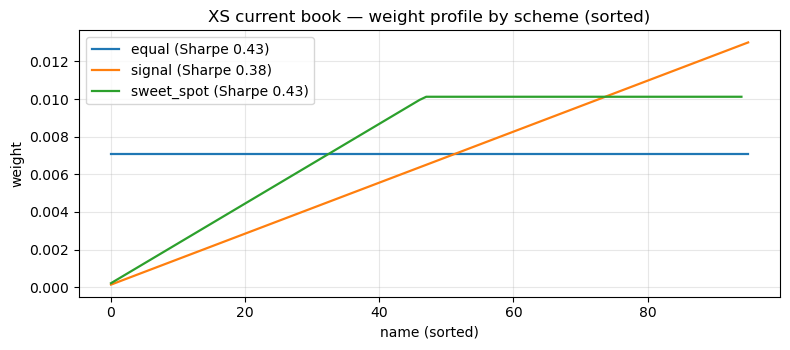

In [7]:
# compare the three within-book weighting schemes (monthly, full sample)
books, sharpes = {}, {}
for wt in ["equal", "signal", "sweet_spot"]:
    c = ms.StrategyConfig(**{**ms.DEFAULT_XS.__dict__, "weighting": wt})
    r = ms.Backtester(md_m, cost_model, 12).run(ms.build_signal(md_m, c), c)
    books[wt] = r.current_weights().sort_values().reset_index(drop=True)
    sharpes[wt] = ms.metrics_from_result(r)["Sharpe"]
print("net Sharpe by within-book weighting (monthly):", {k: round(v, 3) for k, v in sharpes.items()})
print("-> equal is best/most robust; the cross-sectional edge is the SELECTION, not the sizing.")
fig, ax = plt.subplots(figsize=(8, 3.6))
for wt in ["equal", "signal", "sweet_spot"]:
    ax.plot(books[wt].values, lw=1.6, label=f"{wt} (Sharpe {sharpes[wt]:.2f})")
ax.set_title("XS current book — weight profile by scheme (sorted)")
ax.set_xlabel("name (sorted)"); ax.set_ylabel("weight"); ax.legend(); ax.grid(alpha=.3)
fig.savefig(f"{RES}/monthly/figures/xs_weight_schemes.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

Walk-forward OOS Sharpe — XS 0.761, TS 0.691 (vs benchmark 0.601)


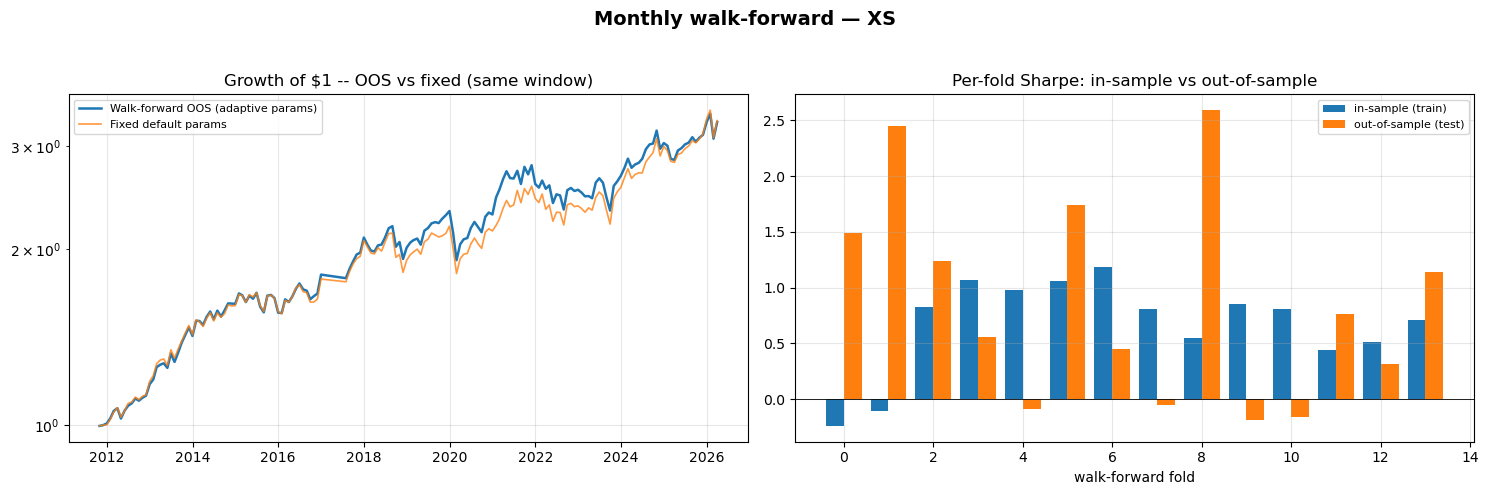


Monthly XS turnover penalty (realistic costs):


,setting,ann_turnover,ann_tcost,gross_sharpe,net_sharpe,net_cagr,net_maxDD
0,full rebalance,2.7380,0.0100,0.5100,0.4350,0.0490,-0.4350
1,band 0.25x pos,2.5200,0.0090,0.5000,0.4300,0.0490,-0.4370
2,band 0.5x pos,2.4190,0.0090,0.4810,0.4160,0.0470,-0.4420
3,rank buffer 50%,1.9280,0.0070,0.5220,0.4690,0.0540,-0.4420
4,band 0.5x + buffer 50%,1.5720,0.0060,0.4790,0.4360,0.0490,-0.4420
5,trade rate 50%,1.7070,0.0060,0.5180,0.4730,0.0560,-0.4360


In [8]:
# walk-forward OOS (monthly only -- needs long history)
bt_m = ms.Backtester(md_m, cost_model, 12)
wf_xs = ms.WalkForwardValidator(bt_m, ms.DEFAULT_XS, {"lookback":[6,9,12],"top_pct":[.1,.2,.3]}, 60, 12).run()
wf_ts = ms.WalkForwardValidator(bt_m, ms.DEFAULT_TS, {"lookback":[6,9,12],"ts_threshold":[0,.25,.5]}, 60, 12).run()
print("Walk-forward OOS Sharpe — XS %.3f, TS %.3f (vs benchmark %.3f)" %
      (wf_xs.metrics()["Sharpe"], wf_ts.metrics()["Sharpe"], ms.compute_metrics(md_m.benchmark)["Sharpe"]))
ms.plot_walkforward(wf_xs, xs_m.net_returns, "Monthly walk-forward — XS",
                    fig_path=f"{RES}/monthly/figures/walkforward_xs.png", data_dir=f"{RES}/monthly/figure_data", slug="walkforward_xs"); plt.show()
sweep_m = ms.turnover_penalty_sweep(md_m, sig_m, ms.DEFAULT_XS, cost_model=cost_model)
sweep_m.to_csv(f"{RES}/monthly/figure_data/turnover_penalty.csv", index=False)
print("\nMonthly XS turnover penalty (realistic costs):"); display(sweep_m.round(3))

## 5. Weekly rebalance (W-FRI, ~2022-11→)

Same strategies on the weekly panel (`periods_per_year=52`, ~52-4-week signal).
Higher turnover → costs and the turnover penalty matter more.

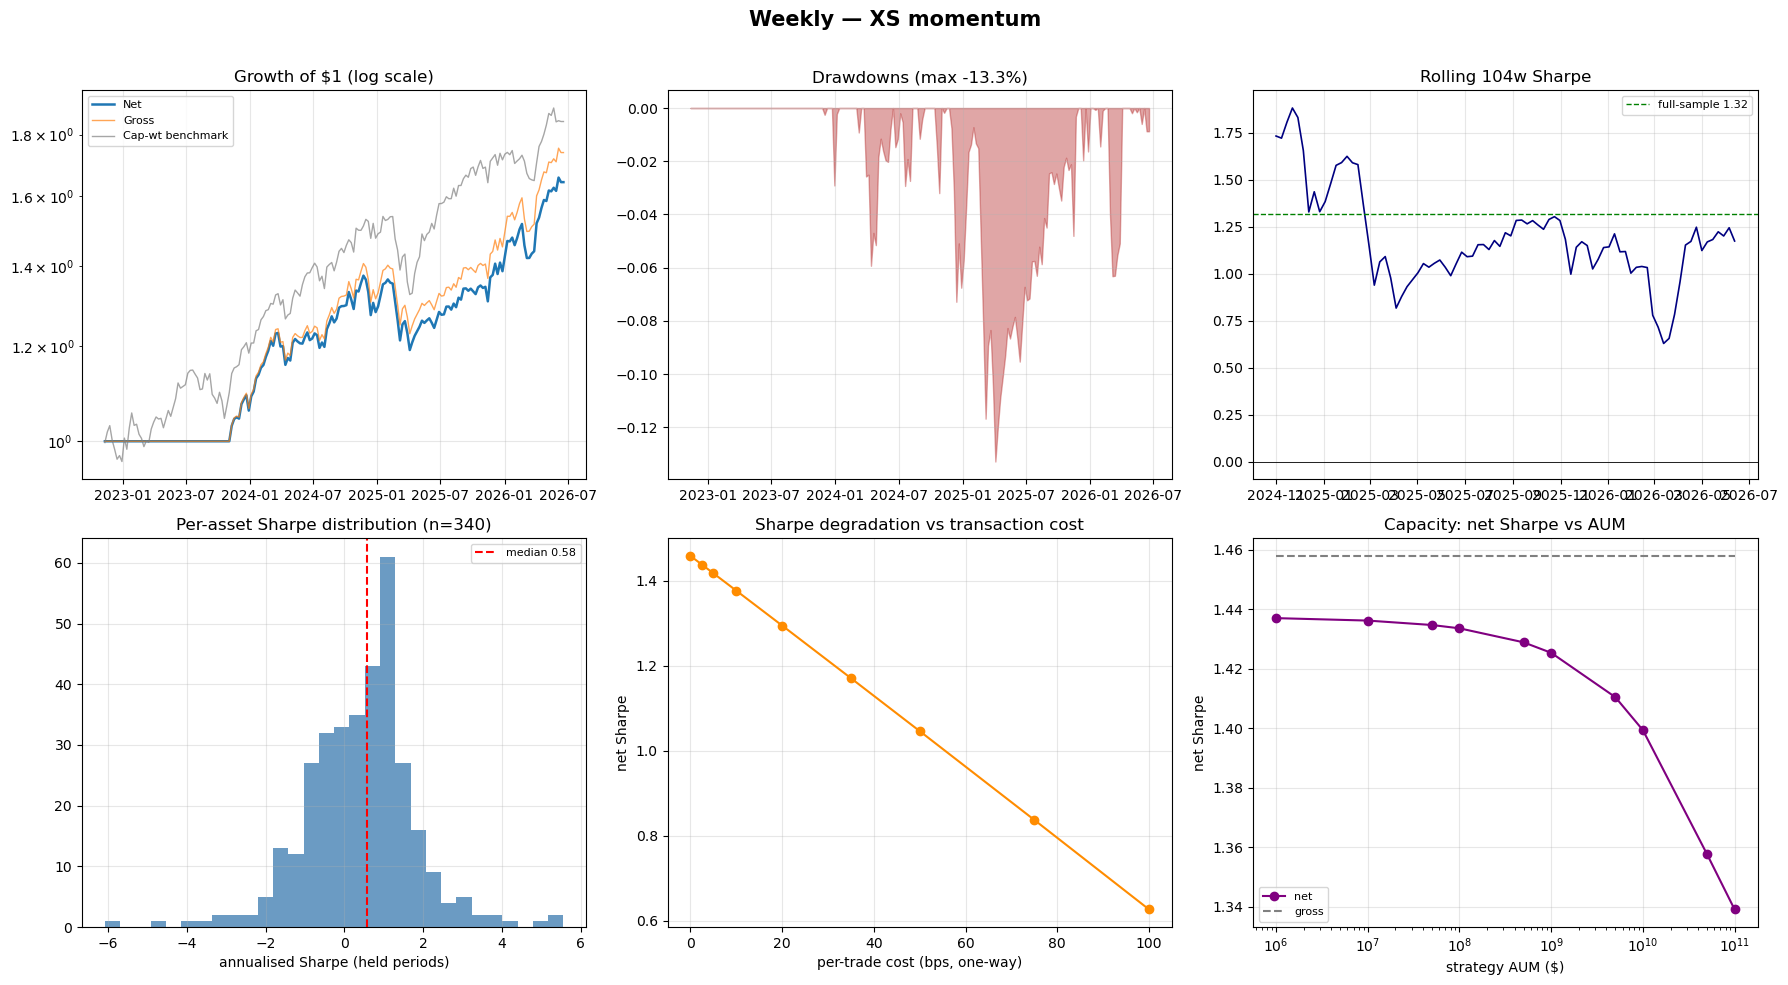

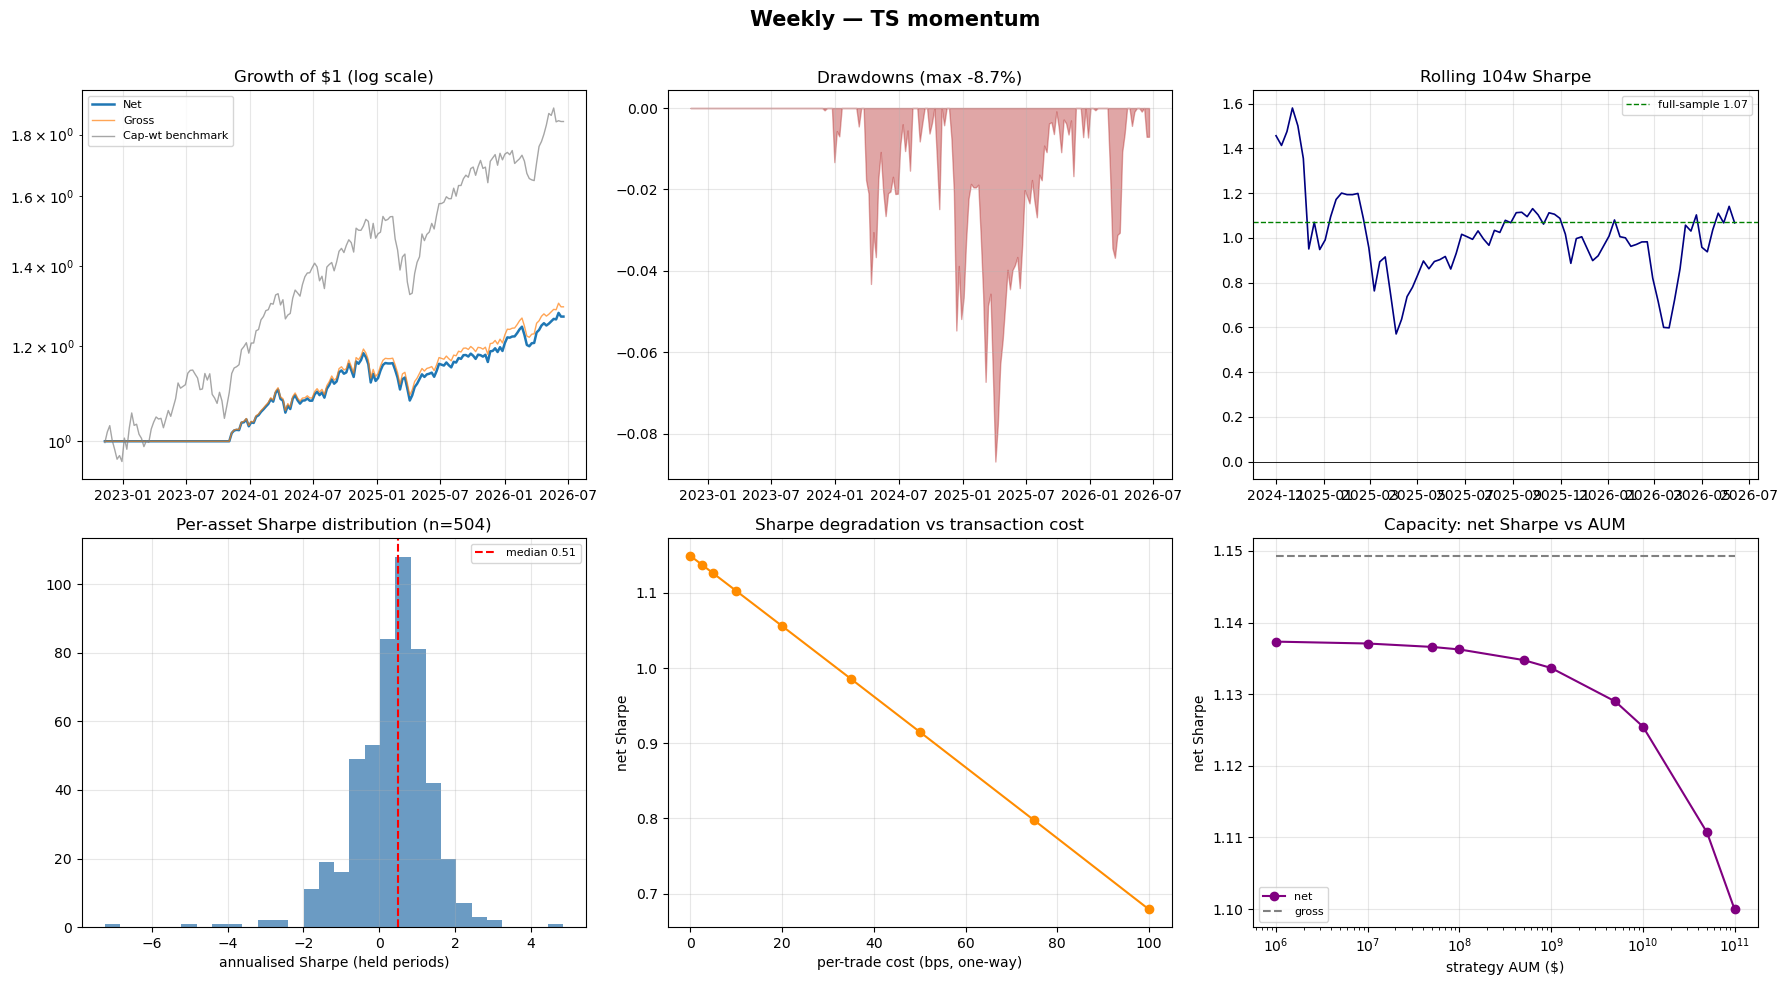

,XS (Weekly),TS (Weekly)
CAGR,0.1473,0.0684
Ann.Return,0.1435,0.0682
Ann.Vol,0.1089,0.0638
Sharpe,1.3173,1.0695
Sortino,1.6413,1.2814
Calmar,1.1084,0.7878
MaxDrawdown,-0.1329,-0.0868
WinRate,0.4574,0.4468
ProfitFactor,1.7427,1.5641
AvgWin,0.0142,0.0081


Weekly XS turnover penalty (realistic costs):


,setting,ann_turnover,ann_tcost,gross_sharpe,net_sharpe,net_cagr,net_maxDD
0,full rebalance,4.5830,0.0160,1.4580,1.3170,0.1470,-0.1330
1,band 0.25x pos,4.1370,0.0140,1.4710,1.3450,0.1520,-0.1300
2,band 0.5x pos,4.0770,0.0140,1.4570,1.3380,0.1570,-0.1380
3,rank buffer 50%,2.3190,0.0080,1.4120,1.3390,0.1450,-0.1370
4,band 0.5x + buffer 50%,1.7080,0.0060,1.4370,1.3860,0.1620,-0.1410
5,trade rate 50%,2.9940,0.0100,1.3770,1.2840,0.1430,-0.1370


In [9]:
res_w, tbl_w = run_frequency(md_w, 52, {"XS": ms.DEFAULT_XS_WEEKLY, "TS": ms.DEFAULT_TS_WEEKLY},
                             cost_model, f"{RES}/weekly", "Weekly")
display(tbl_w)
sig_w = res_w["XS"][1]
sweep_w = ms.turnover_penalty_sweep(md_w, sig_w, ms.DEFAULT_XS_WEEKLY, periods_per_year=52, cost_model=cost_model)
sweep_w.to_csv(f"{RES}/weekly/figure_data/turnover_penalty.csv", index=False)
print("Weekly XS turnover penalty (realistic costs):"); display(sweep_w.round(3))

## 6. Daily rebalance (trading days, ~2022-11→)

`periods_per_year=252`, ~252-21-day signal, default `exec_lag=2` (the scraper's
data is ~2 sessions stale). Includes the **implementation-lag validation**: net
Sharpe is near-flat vs extra lag (the slow signal is timing-insensitive), and daily
turnover is huge unless the penalty is on.

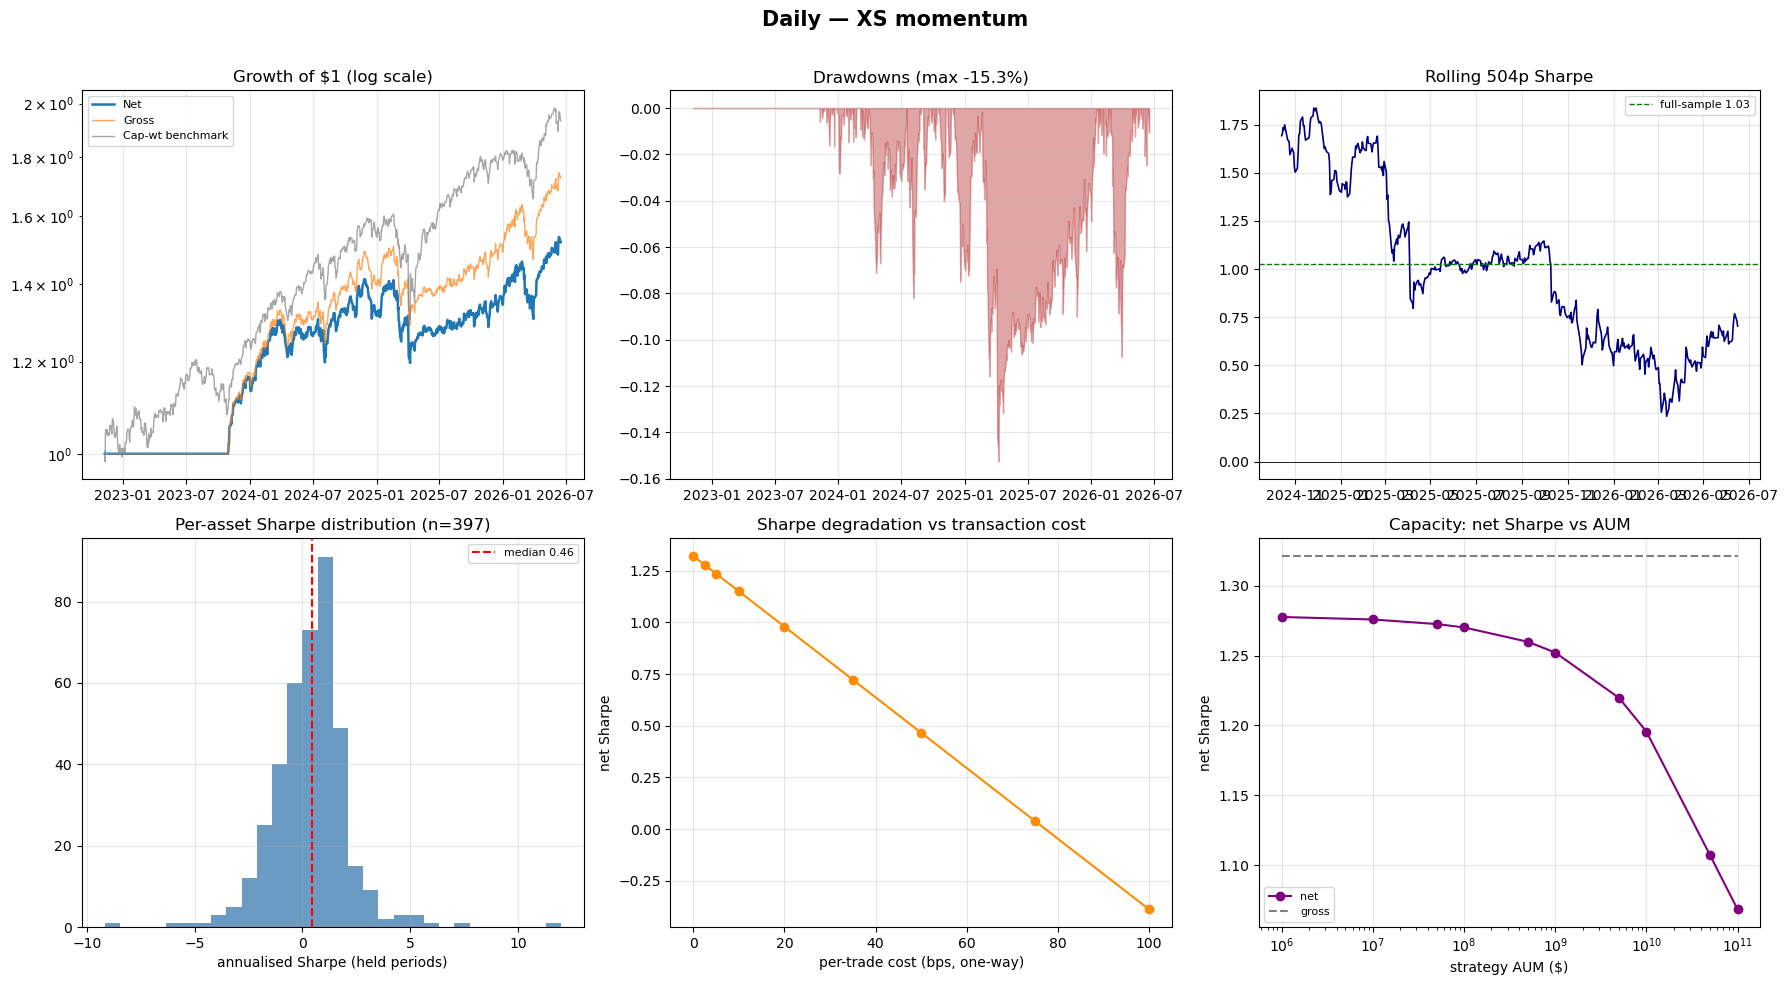

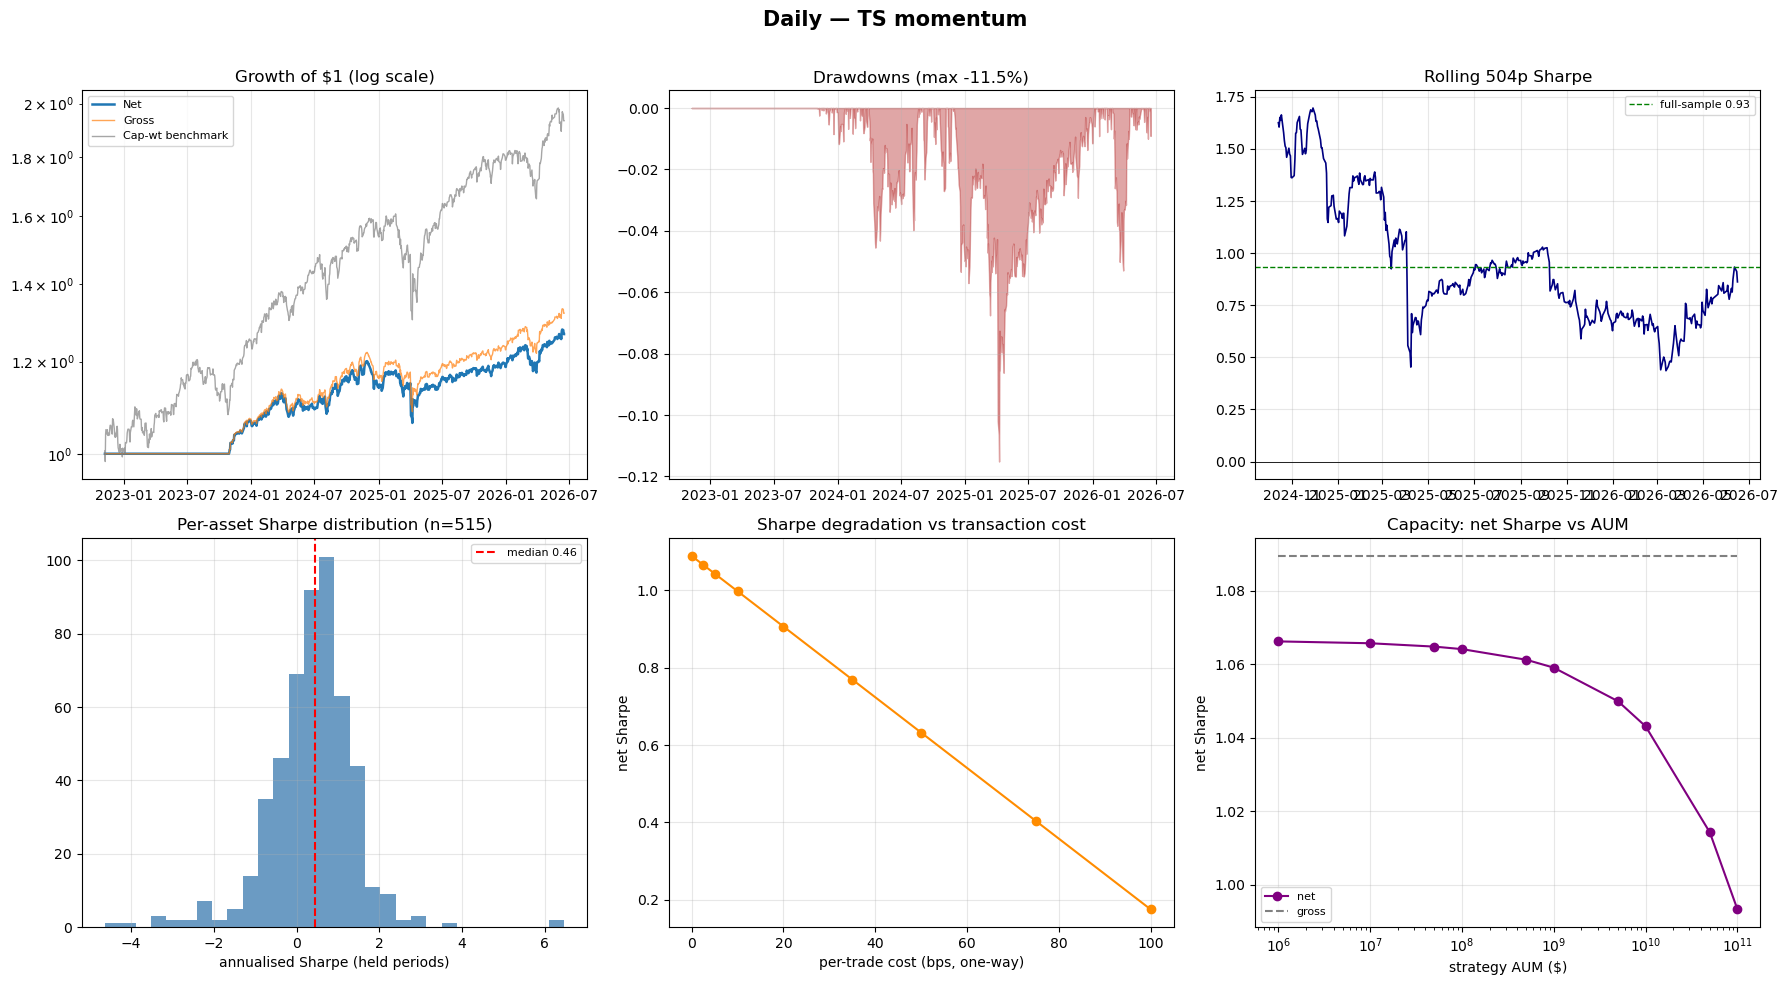

,XS (Daily),TS (Daily)
CAGR,0.1194,0.0659
Ann.Return,0.1196,0.0663
Ann.Vol,0.1165,0.0711
Sharpe,1.0268,0.9333
Sortino,1.1965,1.0810
Calmar,0.7829,0.5723
MaxDrawdown,-0.1525,-0.1151
WinRate,0.3893,0.3861
ProfitFactor,1.2328,1.2237
AvgWin,0.0065,0.0037


Daily exec-lag robustness (trading days):


,exec_lag,sharpe,cagr,ann_vol,maxDD,ann_turnover
0,0,1.0470,0.1210,0.1160,-0.1550,10.0360
1,1,1.0920,0.1280,0.1160,-0.1510,10.0000
2,2,1.0270,0.1190,0.1160,-0.1530,9.9690
3,3,1.0120,0.1170,0.1160,-0.1610,9.9450
4,5,0.9430,0.1080,0.1160,-0.1600,9.9110
5,10,0.9370,0.1080,0.1160,-0.1570,9.8140


turnover penalty: 10.0 -> 2.3 /yr | net Sharpe 1.027 -> 1.310


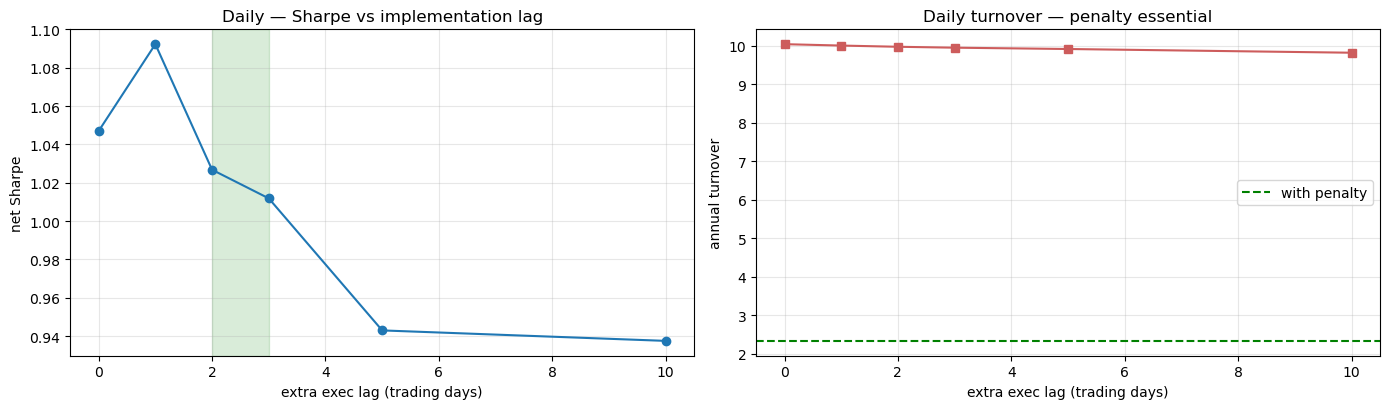

In [10]:
res_d, tbl_d = run_frequency(md_d, 252, {"XS": ms.DEFAULT_XS_DAILY, "TS": ms.DEFAULT_TS_DAILY},
                             cost_model, f"{RES}/daily", "Daily")
display(tbl_d)
sig_d = res_d["XS"][1]
lag_d = ms.lag_sweep(md_d, ms.DEFAULT_XS_DAILY, (0,1,2,3,5,10), "exec_lag", periods_per_year=252, cost_model=cost_model)
lag_d.to_csv(f"{RES}/daily/figure_data/exec_lag_sweep.csv", index=False)
pen = ms.StrategyConfig(**{**ms.DEFAULT_XS_DAILY.__dict__, "rank_buffer":0.5, "no_trade_band":0.5})
xs_dp = ms.Backtester(md_d, cost_model, 252).run(ms.build_signal(md_d, pen), pen)
print("Daily exec-lag robustness (trading days):"); display(lag_d.round(3))
print("turnover penalty: %.1f -> %.1f /yr | net Sharpe %.3f -> %.3f" % (
    ms.metrics_from_result(res_d["XS"][0])["AnnTurnover"], ms.metrics_from_result(xs_dp)["AnnTurnover"],
    ms.metrics_from_result(res_d["XS"][0])["Sharpe"], ms.metrics_from_result(xs_dp)["Sharpe"]))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].plot(lag_d["exec_lag"], lag_d["sharpe"], "o-"); ax[0].axvspan(2,3,alpha=.15,color="green")
ax[0].set_xlabel("extra exec lag (trading days)"); ax[0].set_ylabel("net Sharpe"); ax[0].set_title("Daily — Sharpe vs implementation lag"); ax[0].grid(alpha=.3)
ax[1].plot(lag_d["exec_lag"], lag_d["ann_turnover"], "s-", color="indianred"); ax[1].axhline(ms.metrics_from_result(xs_dp)["AnnTurnover"], ls="--", color="green", label="with penalty")
ax[1].set_xlabel("extra exec lag (trading days)"); ax[1].set_ylabel("annual turnover"); ax[1].set_title("Daily turnover — penalty essential"); ax[1].legend(); ax[1].grid(alpha=.3)
fig.savefig(f"{RES}/daily/figures/lag_validation.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 7. Cross-frequency comparison (same window)

For a fair frequency comparison, all three are evaluated over the **common recent
window** (monthly via `date_slice`; weekly/daily natural). Higher frequency captured
momentum's faster rotations on this sample, at proportionally higher turnover.

Same-window (2022-11-11 -> 2026-06-19), net of realistic costs:


,,Sharpe,Ann.Vol,CAGR,MaxDrawdown,AnnTurnover,AnnTCost
strategy,frequency,,,,,,
XS,monthly,0.8130,0.1310,0.1030,-0.1190,2.8500,0.0100
TS,monthly,0.7370,0.0770,0.0550,-0.0740,1.0410,0.0040
XS,weekly,1.3170,0.1090,0.1470,-0.1330,4.5830,0.0160
TS,weekly,1.0690,0.0640,0.0680,-0.0870,1.5160,0.0050
XS,daily,1.0270,0.1160,0.1190,-0.1530,9.9690,0.0340
TS,daily,0.9330,0.0710,0.0660,-0.1150,3.2530,0.0110


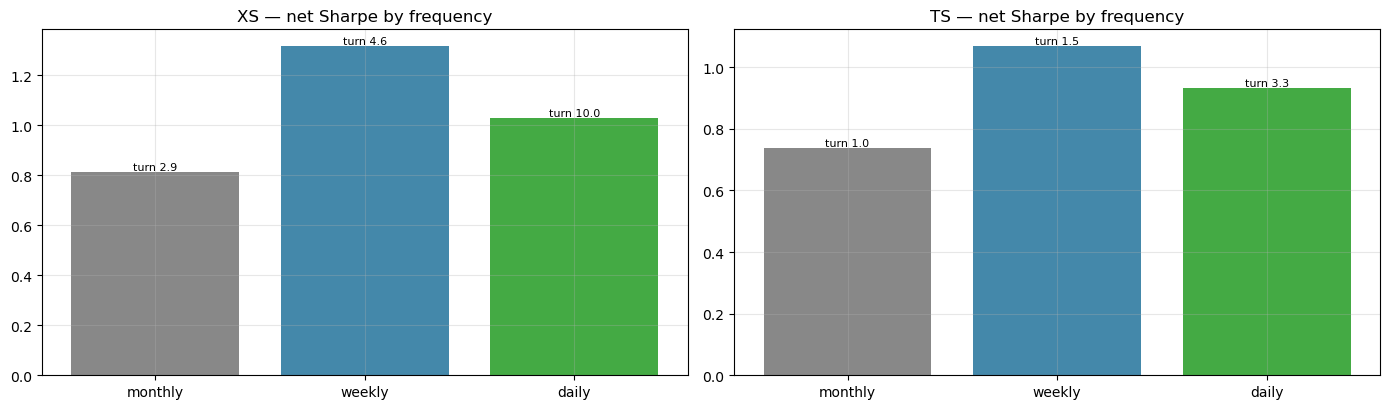

In [11]:
lo, hi = md_w.returns.index.min(), md_w.returns.index.max()
rows = {}
for nm, cfg in [("XS", ms.DEFAULT_XS), ("TS", ms.DEFAULT_TS)]:
    r = ms.Backtester(md_m, cost_model, 12).run(ms.build_signal(md_m, cfg), cfg, date_slice=(lo, hi))
    rows[(nm, "monthly")] = ms.metrics_from_result(r)
for nm, cfg in [("XS", ms.DEFAULT_XS_WEEKLY), ("TS", ms.DEFAULT_TS_WEEKLY)]:
    rows[(nm, "weekly")] = ms.metrics_from_result(ms.Backtester(md_w, cost_model, 52).run(ms.build_signal(md_w, cfg), cfg))
for nm, cfg in [("XS", ms.DEFAULT_XS_DAILY), ("TS", ms.DEFAULT_TS_DAILY)]:
    rows[(nm, "daily")] = ms.metrics_from_result(ms.Backtester(md_d, cost_model, 252).run(ms.build_signal(md_d, cfg), cfg))
comp = pd.DataFrame(rows).T[["Sharpe","Ann.Vol","CAGR","MaxDrawdown","AnnTurnover","AnnTCost"]]
comp.index = pd.MultiIndex.from_tuples(comp.index, names=["strategy","frequency"])
comp.to_csv(f"{RES}/comparison/cross_frequency.csv")
print(f"Same-window ({lo.date()} -> {hi.date()}), net of realistic costs:"); display(comp.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for i, nm in enumerate(["XS", "TS"]):
    sub = comp.xs(nm, level="strategy")
    ax[i].bar(sub.index, sub["Sharpe"], color=["#888","#48a","#4a4"]); ax[i].set_title(f"{nm} — net Sharpe by frequency"); ax[i].grid(alpha=.3)
    for j, v in enumerate(sub["AnnTurnover"]): ax[i].annotate(f"turn {v:.1f}", (j, sub['Sharpe'].iloc[j]), ha="center", va="bottom", fontsize=8)
fig.savefig(f"{RES}/comparison/figures/cross_frequency.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 8. Conclusions

* **Signal.** Risk-adjusted momentum has a modest but real IC (significant at 6m);
  the edge is mostly avoiding losers. XS is signal-weighted (weight ∝ momentum rank); interestingly an *equal*-weight top-quantile is marginally better, because the strongest names mean-revert (decile-10 effect) — so the **selection** is the primary cross-sectional bet.
* **Costs.** Realistic all-in ≈ 1.3%/yr (monthly XS, $100M), ~80%+ FX → **holding a
  USD balance (net-FX) is the biggest lever**; turnover penalty cuts turnover
  30–60% and helps more at higher frequency.
* **By frequency (same window).** Monthly is the robust, validated base case
  (walk-forward OOS still beats the benchmark on risk-adjusted return via drawdown
  control). Weekly/daily captured faster rotations on the recent bull sample at
  much higher turnover — viable only with the turnover penalty on, and the daily
  edge is insensitive to the realistic 2–3 day data lag.
* **Caveats.** Price-return only (no dividends); ETF-holding liquidity proxy; rf=0;
  long-only, **no leverage** (≤1×; vol-targeting only de-risks to cash, so realised vol ≤ ~15%); weekly/daily are short, recent, momentum-friendly samples. Framework
  results, not trading advice.